In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv("CICIDS_Binary_processed.csv")

In [3]:
df.head()

,Bwd Packet Length Max,Flow IAT Std,Flow Duration,PSH Flag Count,Destination Port,Bwd Packet Length Min,Bwd IAT Max,Flow IAT Mean,Min Packet Length,FIN Flag Count,Bwd IAT Std,Fwd Packet Length Min,label_binary
0,0.222427,6.496257e-05,0.001403,1.0,0.001221,0.000000,2.567500e-04,1.263184e-05,0.000000,0.0,0.000068,0.000000,0
1,0.002919,8.363753e-07,0.000002,0.0,0.000809,0.019682,4.000000e-07,6.444444e-07,0.028315,0.0,0.000000,0.017634,0
2,0.040707,5.747613e-02,0.426167,1.0,0.001221,0.000000,8.533428e-02,2.663554e-02,0.000000,0.0,0.058821,0.000000,0
3,0.000000,3.923487e-02,0.048317,1.0,0.001221,0.000000,0.000000e+00,1.610565e-02,0.000000,0.0,0.000000,0.000000,0
4,0.296569,2.499992e-01,0.709303,0.0,0.001221,0.000000,1.310367e-03,4.433154e-02,0.000000,0.0,0.000751,0.000000,1


In [4]:
df.isnull().sum()

Bwd Packet Length Max    0
Flow IAT Std             0
Flow Duration            0
PSH Flag Count           0
Destination Port         0
Bwd Packet Length Min    0
Bwd IAT Max              0
Flow IAT Mean            0
Min Packet Length        0
FIN Flag Count           0
Bwd IAT Std              0
Fwd Packet Length Min    0
label_binary             0
dtype: int64

In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2522362, 13)


In [6]:
df.columns

Index(['Bwd Packet Length Max', 'Flow IAT Std', 'Flow Duration',
       'PSH Flag Count', 'Destination Port', 'Bwd Packet Length Min',
       'Bwd IAT Max', 'Flow IAT Mean', 'Min Packet Length', 'FIN Flag Count',
       'Bwd IAT Std', 'Fwd Packet Length Min', 'label_binary'],
      dtype='object')

In [7]:
print("\nClass distribution:")
print(df['label_binary'].value_counts().sort_index())


Class distribution:
label_binary
0    2096484
1     425878
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['label_binary'])
y = df['label_binary']

# Stratified split (preserves class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())


Train shape: (2017889, 12)
Test shape: (504473, 12)

Training class distribution:
label_binary
0    1677187
1     340702
Name: count, dtype: int64

Testing class distribution:
label_binary
0    419297
1     85176
Name: count, dtype: int64


In [9]:
from collections import Counter
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler

print("Before resampling:", Counter(y_train))

# find smallest class count
min_count = min(Counter(y_train).values())

# safe k_neighbors for SMOTE
k = min(5, max(1, min_count - 1))  

if min_count <= 5:  
    # too few samples for SMOTE → use random oversampling
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    print("Used RandomOverSampler (too few samples for SMOTE).")
else:
    sm = SMOTE(k_neighbors=k, random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f"Used SMOTE with k_neighbors={k}.")

print("After resampling:", Counter(y_train_res))
print("Resampled train shape:", X_train_res.shape)


Before resampling: Counter({0: 1677187, 1: 340702})
Used SMOTE with k_neighbors=5.
After resampling: Counter({0: 1677187, 1: 1677187})
Resampled train shape: (3354374, 12)


### Decision Tree

Decision Tree Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.99      0.99      0.99     85176

    accuracy                           1.00    504473
   macro avg       0.99      0.99      0.99    504473
weighted avg       1.00      1.00      1.00    504473



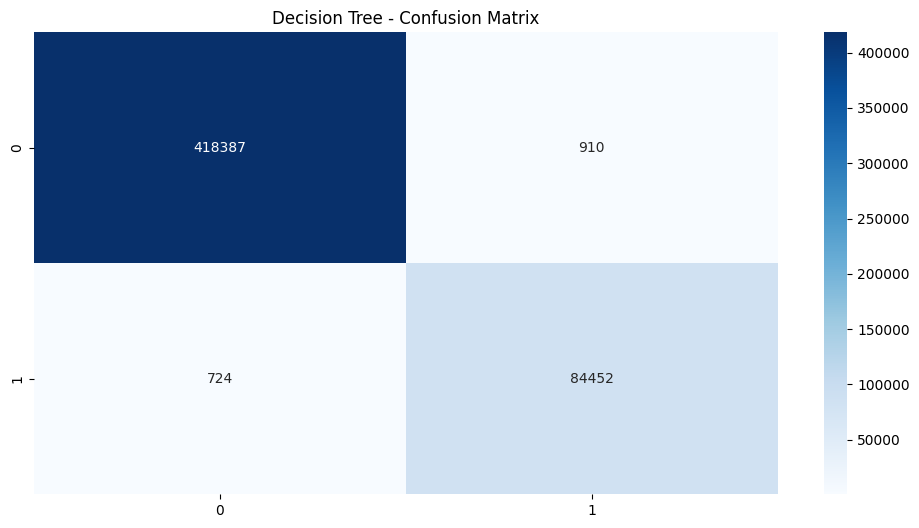

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

# Predictions on test set (NOT resampled, real distribution)
y_pred_dt = dt.predict(X_test)

# Classification report
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


✅ Train Accuracy: 0.9995
✅ Test  Accuracy: 0.9968

Decision Tree Performance (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.99      0.99      0.99     85176

    accuracy                           1.00    504473
   macro avg       0.99      0.99      0.99    504473
weighted avg       1.00      1.00      1.00    504473



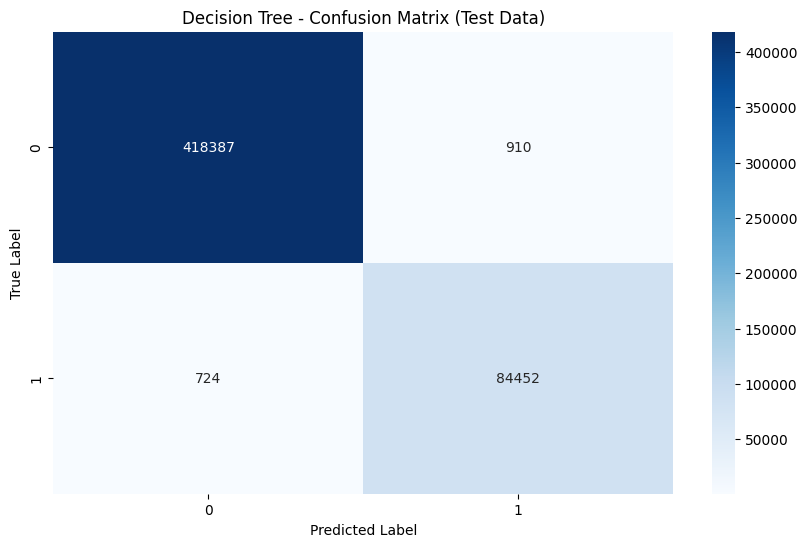

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

# Predictions
y_train_pred = dt.predict(X_train_res)  # on resampled train data
y_test_pred = dt.predict(X_test)        # on real test data

# Accuracy scores
train_acc = accuracy_score(y_train_res, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test  Accuracy: {test_acc:.4f}")

# Classification report (test)
print("\nDecision Tree Performance (Test Data):")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix (Test Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest on SMOTE-balanced training set
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         
    class_weight=None,      # not needed since we used SMOTE
    random_state=42,
    n_jobs=-1               
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

# Classification report
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf) 
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()


### XG Boost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,       # number of boosting rounds
    learning_rate=0.1,      # step size shrinkage
    max_depth=8,            # depth of each tree
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_res, y_train_res)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Report
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()


### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train LightGBM without SMOTE, with class weighting
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=128,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,      # handles class imbalance
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)   #Note: use X_train, y_train (not SMOTE version)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Report
print("LightGBM Performance (with class weights, no SMOTE):")
print(classification_report(y_test, y_pred_lgbm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LightGBM - Confusion Matrix (No SMOTE, Class Weights)")
plt.show()


### LSTM

In [ ]:
import numpy as np

# Convert train/test to numpy
X_train_lstm = np.array(X_train_res)
y_train_lstm = np.array(y_train_res)
X_test_lstm = np.array(X_test)
y_test_lstm = np.array(y_test)

# Reshape for LSTM: (samples, timesteps, features)
# Here timesteps = 1 (each row is one event)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], 1, X_train_lstm.shape[1]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], 1, X_test_lstm.shape[1]))

print("Train shape for LSTM:", X_train_lstm.shape)
print("Test shape for LSTM:", X_test_lstm.shape)


In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# One-hot encode labels for multiclass classification
num_classes = len(np.unique(y_train_lstm))
y_train_cat = to_categorical(y_train_lstm, num_classes=num_classes)
y_test_cat = to_categorical(y_test_lstm, num_classes=num_classes)

# Build LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(
    X_train_lstm, y_train_cat,
    epochs=10, batch_size=512,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print("LSTM Test Accuracy:", acc)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_probs = model.predict(X_test_lstm)

# Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Classification report
print("LSTM Performance:")
print(classification_report(y_true_classes, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LSTM - Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE

def preprocess_for_linear_models(df, target_col="label_multi_enc", test_size=0.2, random_state=42):
    """
    Preprocess dataset for Logistic Regression / KNN / SVM:
    - Cleans dataset
    - Train-test split
    - Yeo-Johnson Transformation
    - Min-Max Scaling
    - SMOTE on training set
    """

    print("🔹 Starting preprocessing...")

    # ✅ Step 1 — Clean data
    print("1️⃣ Cleaning data...")
    df = df.copy()
    df = df.dropna()                          # Drop any NaN rows
    df = df.select_dtypes(include=[np.number]) # Keep only numeric columns

    if target_col not in df.columns:
        raise ValueError(f"❌ Target column '{target_col}' not found in dataframe.")

    # ✅ Step 2 — Split features & target
    print("2️⃣ Splitting features and target...")
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # ✅ Step 3 — Train-Test Split
    print("3️⃣ Performing stratified train-test split...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    print(f"   → Train: {X_train.shape}, Test: {X_test.shape}")

    # ✅ Step 4 — Yeo-Johnson Transformation
    print("4️⃣ Applying Yeo-Johnson transformation...")
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    X_train_trans = pt.fit_transform(X_train)
    X_test_trans = pt.transform(X_test)

    # ✅ Step 5 — Min-Max Scaling
    print("5️⃣ Applying Min-Max scaling...")
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_trans)
    X_test_scaled = scaler.transform(X_test_trans)

    # ✅ Step 6 — SMOTE (train only)
    print("6️⃣ Applying SMOTE on training data...")
    sm = SMOTE(random_state=random_state, k_neighbors=5)
    X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

    print("✅ Preprocessing complete!")
    print(f"   → After SMOTE: {X_train_res.shape}")
    print(f"   → y_train unique classes: {len(np.unique(y_train_res))}")

    # ✅ Step 7 — Return everything
    return X_train_res, X_test_scaled, y_train_res, y_test, pt, scaler


In [ ]:
X_train_res, X_test_scaled, y_train_res, y_test, pt, scaler = preprocess_for_linear_models(df)


In [ ]:
import joblib
joblib.dump(pt, "yeo_johnson_bin.pkl")
joblib.dump(scaler, "minmax_scaler_bin.pkl")
print("✅ Transformers saved!")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before transformation (original data)
sns.kdeplot(df.iloc[:,0], fill=True)
plt.title("Feature 1 Before Yeo-Johnson")
plt.show()

# After transformation
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transformed = pt.fit_transform(df.drop(columns=['label_multi_enc']))

sns.kdeplot(transformed[:,0], fill=True)
plt.title("Feature 1 After Yeo-Johnson")
plt.show()


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess once
X_train_res, X_test_scaled, y_train_res, y_test = preprocess_for_linear_models(df)

# Train Logistic Regression
lr = LogisticRegression(max_iter=500, n_jobs=-1)
lr.fit(X_train_res, y_train_res)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Report
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Preprocess (same function as before)
X_train_res_knn, X_test_scaled_knn, y_train_res_knn, y_test_knn = preprocess_for_linear_models(df)

# ---- Train KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  
knn.fit(X_train_res_knn, y_train_res_knn)

# ---- Predict
y_pred_knn = knn.predict(X_test_scaled_knn)

# ---- Report
print("KNN Performance:")
print(classification_report(y_test_knn, y_pred_knn))

# ---- Confusion Matrix
cm = confusion_matrix(y_test_knn, y_pred_knn)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("K-Nearest Neighbors – Confusion Matrix")
plt.show()


In [ ]:
# Updated KNN evaluation: train on SMOTE but show direct outputs 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- 1) Split original data (no SMOTE yet) ----
X = df.drop(columns=['label_multi_enc'])
y = df['label_multi_enc']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Original train shape:", X_train_orig.shape)
print("Original test shape: ", X_test_orig.shape)

# ---- 2) Fit Yeo-Johnson + MinMax on the original train subset ----
pt = PowerTransformer(method='yeo-johnson')
X_train_trans = pt.fit_transform(X_train_orig)
X_test_trans = pt.transform(X_test_orig)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_trans)
X_test_scaled = scaler.transform(X_test_trans)

# ---- 3) Apply SMOTE only to the training set (to get X_train_res, y_train_res) ----
print("\nBefore SMOTE (train class counts):")
print(pd.Series(y_train_orig).value_counts().sort_index())

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train_orig)

print("\nAfter SMOTE (train class counts):")
print(pd.Series(y_train_res).value_counts().sort_index())
print("Resampled train shape:", X_train_res.shape)

# ---- 4) Train KNN on SMOTE-resampled training data ----
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("\nTraining KNN...")
knn.fit(X_train_res, y_train_res)
print("KNN training complete.")

# ---- 5) Evaluate on non-SMOTE original train subset and on test subset ----
y_train_pred_orig = knn.predict(X_train_scaled)   # evaluate on original (non-SMOTE) train
y_test_pred = knn.predict(X_test_scaled)

train_acc = accuracy_score(y_train_orig, y_train_pred_orig)
test_acc = accuracy_score(y_test_orig, y_test_pred)
train_bal_acc = balanced_accuracy_score(y_train_orig, y_train_pred_orig)
test_bal_acc = balanced_accuracy_score(y_test_orig, y_test_pred)
train_macro_f1 = f1_score(y_train_orig, y_train_pred_orig, average='macro')
test_macro_f1 = f1_score(y_test_orig, y_test_pred, average='macro')

print(f"\n✅ KNN Train Accuracy (on ORIGINAL train subset): {train_acc:.4f}")
print(f"✅ KNN Test  Accuracy (on test subset):              {test_acc:.4f}")
print(f"🔢 KNN Train Balanced Accuracy: {train_bal_acc:.4f}")
print(f"🔢 KNN Test  Balanced Accuracy: {test_bal_acc:.4f}")
print(f"🔢 KNN Train Macro-F1: {train_macro_f1:.4f}")
print(f"🔢 KNN Test  Macro-F1: {test_macro_f1:.4f}\n")

# ---- 6) Classification reports with 4 decimal places ----
train_report = classification_report(y_train_orig, y_train_pred_orig, digits=4, output_dict=True)
test_report = classification_report(y_test_orig, y_test_pred, digits=4, output_dict=True)

train_report_df = pd.DataFrame(train_report).transpose()
test_report_df = pd.DataFrame(test_report).transpose()

print("🔹 KNN Performance on ORIGINAL Train subset:\n")
display(train_report_df.round(4))

print("\n🔹 KNN Performance on Test subset:\n")
display(test_report_df.round(4))

# ---- 7) Confusion matrix (test) - display inline ----
cm_test = confusion_matrix(y_test_orig, y_test_pred)
plt.figure(figsize=(12,6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("KNN - Confusion Matrix (Test Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



In [ ]:
import joblib
joblib.dump(pt, "yeo_johnson_bin.pkl")
joblib.dump(scaler, "minmax_scaler_bin.pkl")

### Linear SVM

In [ ]:
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Preprocess (same as before)
X_train_res_svm, X_test_scaled_svm, y_train_res_svm, y_test_svm = preprocess_for_linear_models(df)

# ===========================================
# Linear SVM
# ===========================================
linear_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
linear_svm.fit(X_train_res_svm, y_train_res_svm)

y_pred_linear = linear_svm.predict(X_test_scaled_svm)

print("\n--- Linear SVM Performance ---")
print(classification_report(y_test_svm, y_pred_linear))

# Confusion Matrix
cm_linear = confusion_matrix(y_test_svm, y_pred_linear)
plt.figure(figsize=(12,6))
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues")
plt.title("Linear SVM - Confusion Matrix")
plt.show()

### RBF SVM

In [ ]:
# ===========================================
# RBF SVM 
# ===========================================
#sample subset to speed up
sample_size = 200000  # adjust smaller if it’s too slow
X_train_sample = X_train_res_svm[:sample_size]
y_train_sample = y_train_res_svm[:sample_size]

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train_sample, y_train_sample)

y_pred_rbf = rbf_svm.predict(X_test_scaled_svm)

print("\n--- RBF SVM Performance ---")
print(classification_report(y_test_svm, y_pred_rbf))

# Confusion Matrix
cm_rbf = confusion_matrix(y_test_svm, y_pred_rbf)
plt.figure(figsize=(12,6))
sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues")
plt.title("RBF SVM - Confusion Matrix")
plt.show()
